# Mini Project: Data Analysis with Python
# Videogame Sales Analysis

In [1]:
# Import the KaggleHub library to get the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anandshaw2001/video-game-sales")

print("Path to dataset files:", path)

Path to dataset files: /Users/sergiogarcia/.cache/kagglehub/datasets/anandshaw2001/video-game-sales/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.multiclass import *
from sklearn.linear_model import *
from sklearn.tree import *
from sklearn.ensemble import *
from sklearn.svm import *
from sklearn.neighbors import *
from sklearn.naive_bayes import *
from sklearn.preprocessing import *
from sklearn.decomposition import *
from sklearn.pipeline import *

In [3]:
#Read the dataset
df = pd.read_csv(path + "/vgsales.csv")
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset has 16598 rows and 11 columns.


In [4]:
#Check if there are any missing values
print(df.isnull().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [5]:
#Remove the rows with missing values
df.dropna(inplace=True)
#Check if there are any missing values after removing the rows with missing values
print(df.isnull().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [7]:
# Let's filter the dataset to include only games released in from 2010-2020.
df_recent = df[df['Year'] >= 2010]
print(f'The dataset has {df_recent.shape[0]} rows and {df_recent.shape[1]} columns after filtering for recent years.')

The dataset has 5134 rows and 11 columns after filtering for recent years.


In [8]:
# Checking the unique values in the Platform, Genre, and Publisher columns to understand the diversity of the dataset.
print(df_recent['Platform'].unique())
print(df_recent['Genre'].unique())
print(df_recent['Publisher'].unique())

['X360' 'PS3' 'DS' '3DS' 'PS4' 'Wii' 'XOne' 'WiiU' 'PC' 'PSP' 'PSV' 'PS2']
['Misc' 'Action' 'Role-Playing' 'Shooter' 'Racing' 'Platform' 'Simulation'
 'Sports' 'Fighting' 'Strategy' 'Adventure' 'Puzzle']
['Microsoft Game Studios' 'Take-Two Interactive' 'Nintendo' 'Activision'
 'Sony Computer Entertainment' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' '505 Games' 'Sony Computer Entertainment Europe'
 'Warner Bros. Interactive Entertainment' 'Capcom' 'Sega'
 'Namco Bandai Games' 'Konami Digital Entertainment' 'MTV Games'
 'Disney Interactive Studios' 'Majesco Entertainment' 'THQ' 'Level 5'
 'Square Enix' 'Deep Silver' 'NCSoft' 'Valve Software' 'LucasArts' 'Valve'
 'Hello Games' 'GungHo' 'Atlus' 'Codemasters' 'Focus Home Interactive'
 'Mastertronic' 'City Interactive' 'Slightly Mad Studios' 'Tecmo Koei'
 'Marvelous Entertainment' 'Mojang' 'mixi, Inc' 'Unknown'
 'Avanquest Software' 'Nippon Ichi Software' 'Funbox Media'
 'Ubisoft Annecy' 'Sony Computer Entertainment America' 'Natsume'

In [9]:
# The Sales columns are in millions of sold units.
# Change columns to add the "Millions" suffix to make it clear.
df_recent.rename(columns={'Global_Sales': 'Global_Sales_Millions',
                          'NA_Sales': 'NA_Sales_Millions',
                          'EU_Sales': 'EU_Sales_Millions',
                          'JP_Sales': 'JP_Sales_Millions',
                          'Other_Sales': 'Other_Sales_Millions'}, inplace=True)
print(df_recent.head())

    Rank                            Name Platform    Year         Genre  \
15    16              Kinect Adventures!     X360  2010.0          Misc   
16    17              Grand Theft Auto V      PS3  2013.0        Action   
23    24              Grand Theft Auto V     X360  2013.0        Action   
26    27     Pokemon Black/Pokemon White       DS  2010.0  Role-Playing   
29    30  Call of Duty: Modern Warfare 3     X360  2011.0       Shooter   

                 Publisher  NA_Sales_Millions  EU_Sales_Millions  \
15  Microsoft Game Studios              14.97               4.94   
16    Take-Two Interactive               7.01               9.27   
23    Take-Two Interactive               9.63               5.31   
26                Nintendo               5.57               3.28   
29              Activision               9.03               4.28   

    JP_Sales_Millions  Other_Sales_Millions  Global_Sales_Millions  
15               0.24                  1.67                  21.82  
16

/var/folders/09/2dl_l7zn5y3_j5dfck9c8ymm0000gn/T/ipykernel_72785/4198906387.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent.rename(columns={'Global_Sales': 'Global_Sales_Millions',


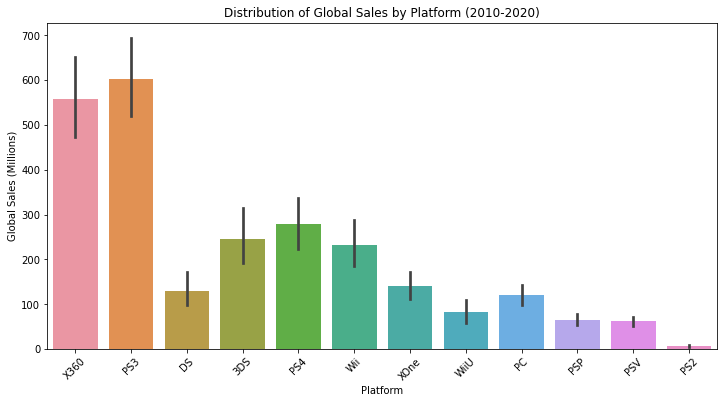

In [10]:
# Let's check the distribution of Global Sales based on the platform.
plt.figure(figsize=(12, 6))
sns.barplot(x='Platform', y='Global_Sales_Millions', data=df_recent, estimator=np.sum)
plt.title('Distribution of Global Sales by Platform (2010-2020)')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

In [11]:
df_recent.groupby('Platform')['Global_Sales_Millions'].sum()

Platform
3DS     246.27
DS      129.64
PC      119.78
PS2       6.10
PS3     602.44
PS4     278.10
PSP      64.27
PSV      61.60
Wii     232.33
WiiU     81.86
X360    556.95
XOne    141.06
Name: Global_Sales_Millions, dtype: float64

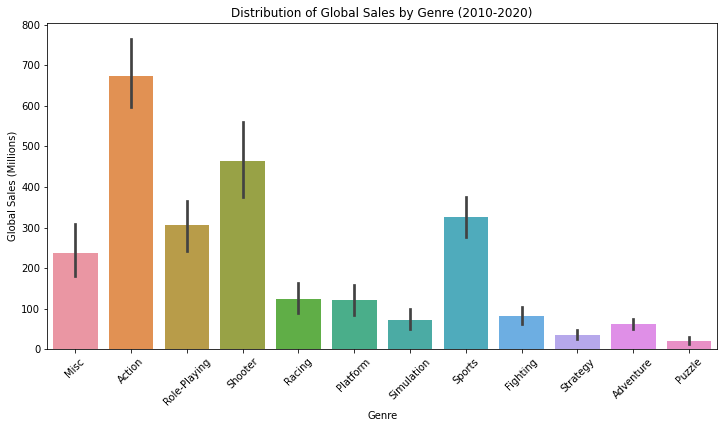

In [12]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Genre', y='Global_Sales_Millions', data=df_recent, estimator=np.sum)
plt.title('Distribution of Global Sales by Genre (2010-2020)')
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.xticks(rotation=45)
plt.show()

In [13]:
df_recent.groupby('Genre')['Global_Sales_Millions'].sum()

Genre
Action          673.46
Adventure        61.03
Fighting         82.08
Misc            238.05
Platform        120.67
Puzzle           21.23
Racing          123.68
Role-Playing    305.71
Shooter         462.80
Simulation       71.15
Sports          324.80
Strategy         35.74
Name: Global_Sales_Millions, dtype: float64

In [14]:
df_recent.groupby(['Publisher', 'Year'])['Global_Sales_Millions'].sum().sort_values(ascending=False).head(5)

Publisher        Year  
Electronic Arts  2010.0    81.38
                 2011.0    72.25
Activision       2010.0    63.39
Nintendo         2010.0    61.07
                 2012.0    56.47
Name: Global_Sales_Millions, dtype: float64

In [15]:
# Here we can aggregate by Publisher, Genre, Year and Name to find the top selling games in the dataset.
x = df_recent.groupby(['Publisher', 'Genre','Year','Name'])[['Global_Sales_Millions', 'NA_Sales_Millions', 'EU_Sales_Millions', 'JP_Sales_Millions', 'Other_Sales_Millions']].sum().sort_values('Global_Sales_Millions', ascending=False).head(10)
print(x.iloc[0])

Global_Sales_Millions    37.78
NA_Sales_Millions        16.64
EU_Sales_Millions        14.58
JP_Sales_Millions         1.03
Other_Sales_Millions      5.52
Name: (Take-Two Interactive, Action, 2013.0, Grand Theft Auto V), dtype: float64


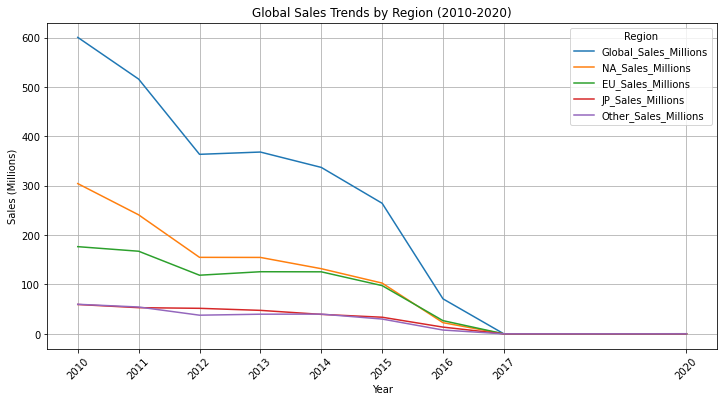

In [16]:
#Plotting the global sales trends by region over the years.
to_plot = df_recent.groupby('Year')[['Global_Sales_Millions', 'NA_Sales_Millions', 'EU_Sales_Millions', 'JP_Sales_Millions', 'Other_Sales_Millions']].sum()
to_plot.plot(kind='line', figsize=(12, 6))
plt.title('Global Sales Trends by Region (2010-2020)')
plt.xlabel('Year')
plt.ylabel('Sales (Millions)')
plt.xticks(to_plot.index, rotation=45)
plt.legend(title='Region')
plt.grid()
plt.show()

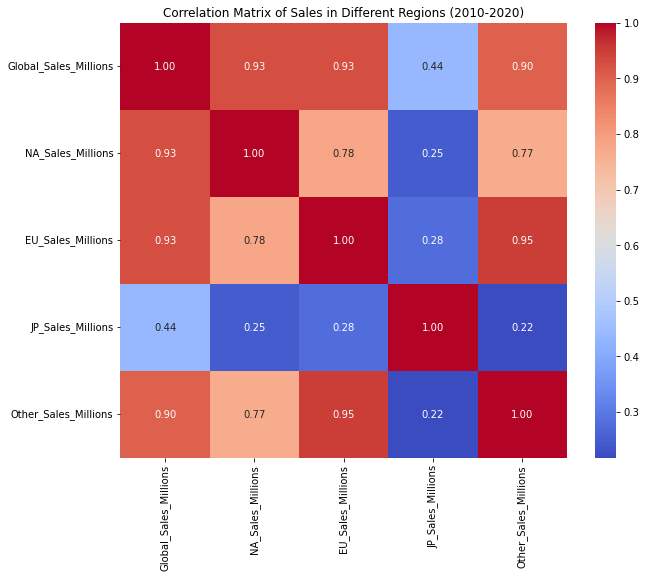

In [17]:
# Let's check the correlation between the sales in different regions.
sales_columns = ['Global_Sales_Millions', 'NA_Sales_Millions', 'EU_Sales_Millions', 'JP_Sales_Millions', 'Other_Sales_Millions']
correlation_matrix = df_recent[sales_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Sales in Different Regions (2010-2020)')
plt.show()

In [18]:
# Linear regression to predict global sales based on genre and sales in different regions.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Define the features and target variable
X = df_recent[['Genre', 'NA_Sales_Millions', 'EU_Sales_Millions', 'JP_Sales_Millions', 'Other_Sales_Millions']]
y = df_recent['Global_Sales_Millions']
# Define the column transformer to one-hot encode the Genre column
preprocessor = ColumnTransformer(
    transformers=[
        ('genre', OneHotEncoder(), ['Genre'])
    ],
    remainder='passthrough'
)
# Create a pipeline that combines the preprocessor with a linear regression model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
# Fit the model
pipeline.fit(X, y)
# Print the coefficients of the model
print("Coefficients of the model:")
print(pipeline.named_steps['model'].coef_)  
print("Intercept of the model:")
print(pipeline.named_steps['model'].intercept_)



Coefficients of the model:
[3.59758855e+09 3.59758855e+09 3.59758855e+09 3.59758855e+09
 3.59758855e+09 3.59758855e+09 3.59758855e+09 3.59758855e+09
 3.59758855e+09 3.59758855e+09 3.59758855e+09 3.59758855e+09
 1.00001678e+00 1.00040596e+00 9.99839010e-01 9.97914915e-01]
Intercept of the model:
-3597588549.9554596
